In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import json

In [2]:
df = pd.read_csv("../processed/tx_cvap_equipment_data.csv", dtype={"region_id": str})
df

,region_id,cvap_white,cvap_black,cvap_hispanic,cvap_asian,cvap_other,cvap_total,equipment_quality
0,4800100000,26950,8695,6770,245,1820,44480,0.742807
1,4800300000,5465,345,5450,20,165,11445,0.751176
2,4800500000,40595,7610,8720,690,2550,60165,0.744338
3,4800700000,14395,255,4440,230,665,19985,0.524348
4,4800900000,5935,25,365,20,155,6500,0.528000
...,...,...,...,...,...,...,...,...
223,4849700000,42350,730,6615,275,1175,51145,0.521412
224,4849900000,31235,1480,2615,130,745,36205,0.571892
225,4850100000,1570,10,2315,30,165,4090,0.710000
226,4850300000,10830,170,1680,0,285,12965,0.640000


In [3]:
# Compute weighted KDE evaluated on a grid
def weighted_kde(x, weights, grid):
    kde = gaussian_kde(x, weights=weights)
    y = kde(grid)
    return y / y.sum()

In [4]:
quality = df["equipment_quality"].values

quality_grid = np.linspace(
    quality.min(),
    quality.max(),
    200
)

groups = {
    "white": "cvap_white",
    "black": "cvap_black",
    "hispanic": "cvap_hispanic",
    "asian": "cvap_asian",
    "other": "cvap_other"
}

curves = {}

for group, col in groups.items():
    work = pd.DataFrame({
        "quality": df["equipment_quality"],
        "group_cvap": df[col],
        "cvap_total": df["cvap_total"]
    })

    # Hard validity filter
    work = work[
        (work["cvap_total"] > 0) &
        (work["group_cvap"] >= 0) &
        (work["quality"].notna())
    ]

    if work.empty:
        continue

    weights = work["group_cvap"] / work["cvap_total"]

    # Redundant but harmless safety
    weights = weights.clip(lower=0)

    curves[group] = weighted_kde(
        work["quality"].values,
        weights.values,
        quality_grid
    )

work.describe()

,quality,group_cvap,cvap_total
count,227.000000,227.000000,2.270000e+02
mean,0.649980,1876.215859,8.239130e+04
std,0.105226,6372.206660,2.708600e+05
min,0.290000,0.000000,1.400000e+02
25%,0.544144,83.500000,4.410000e+03
50%,0.710000,280.000000,1.345500e+04
75%,0.743004,910.000000,4.044500e+04
max,0.832500,61295.000000,2.845385e+06


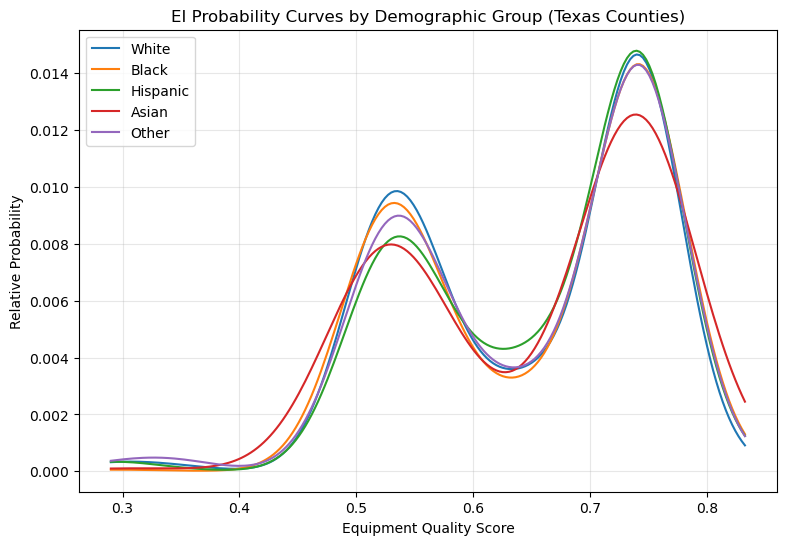

In [5]:
plt.figure(figsize=(9, 6))

for group, y in curves.items():
    plt.plot(
        quality_grid,
        y,
        label=group.capitalize()
    )

plt.xlabel("Equipment Quality Score")
plt.ylabel("Relative Probability")
plt.title("EI Probability Curves by Demographic Group (Texas Counties)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [8]:
ei_equipment_points = {}

for group, yvals in curves.items():
    ei_equipment_points[group] = [
        {"x": float(x), "y": float(y)}
        for x, y in zip(quality_grid, yvals)
    ]

with open("../processed/tx_ei_equipment_curves.json", "w") as f:
    json.dump(ei_equipment_points, f, indent=2)

print("Created JSON with X and Y points only")

Created JSON with X and Y points only
